In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os

# List datasets attached
print(os.listdir("/kaggle/input"))

# List contents of RSNA Bone Age dataset
dataset_path = "/kaggle/input/rsna-bone-age"
print(os.listdir(dataset_path))


['rsna-bone-age']
['boneage-training-dataset.csv', 'boneage-training-dataset', 'boneage-test-dataset', 'boneage-test-dataset.csv']


Train shape: (12611, 3)
Test shape: (200, 2)
    male     sex
0  False  Female
1  False  Female
2  False  Female
3   True    Male
4  False  Female
5   True    Male
6   True    Male
7   True    Male
8   True    Male
9   True    Male
Columns: Index(['id', 'boneage', 'male', 'sex'], dtype='object')
Missing values:
 id         0
boneage    0
male       0
sex        0
dtype: int64
Bone age range: 1 - 228
Unique sexes: ['Female' 'Male']


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


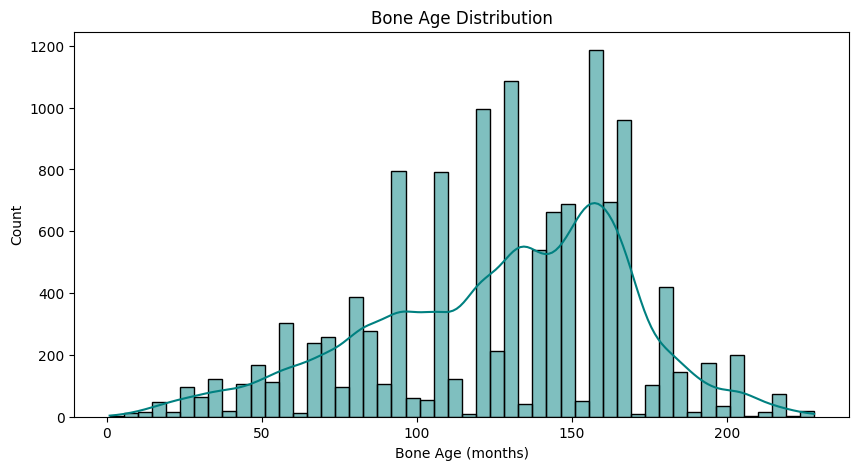

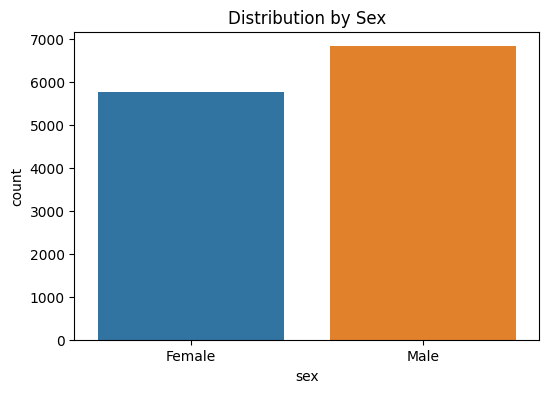

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


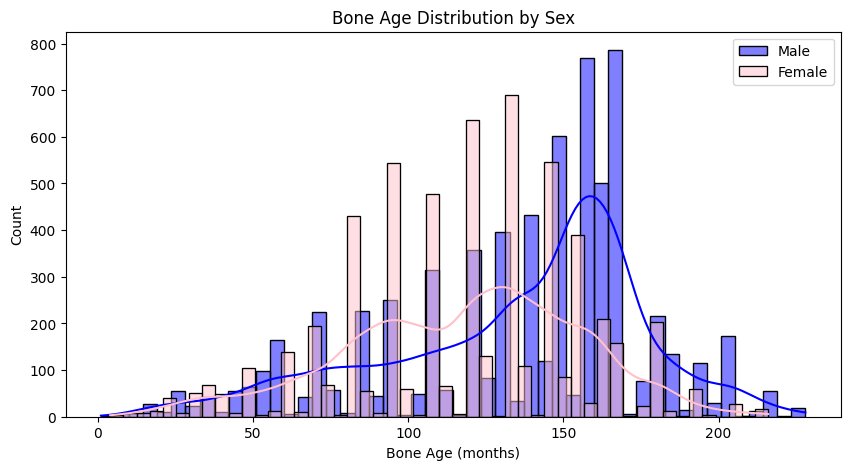

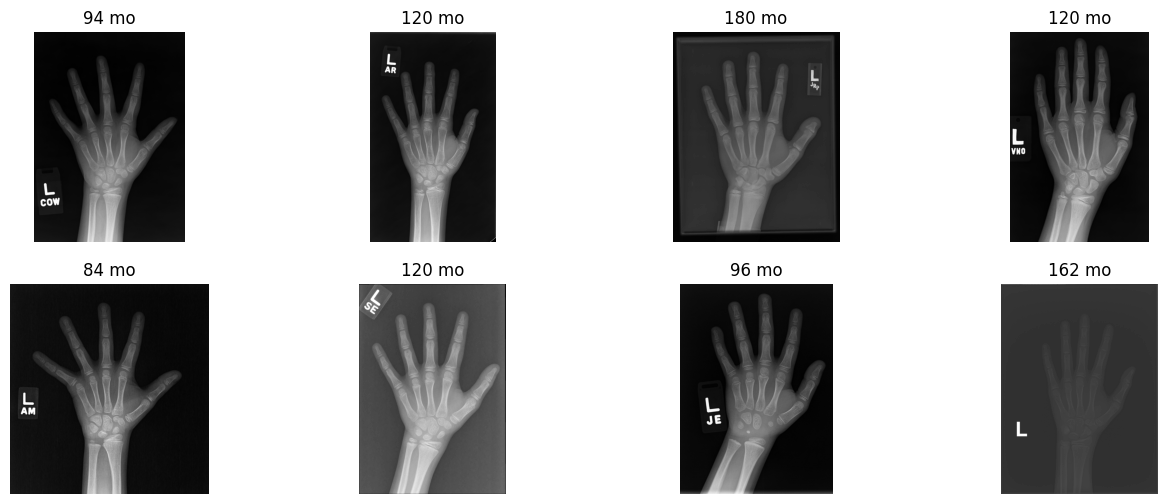

Image size stats (WxH): 885 - 2016 x 1031 - 2507


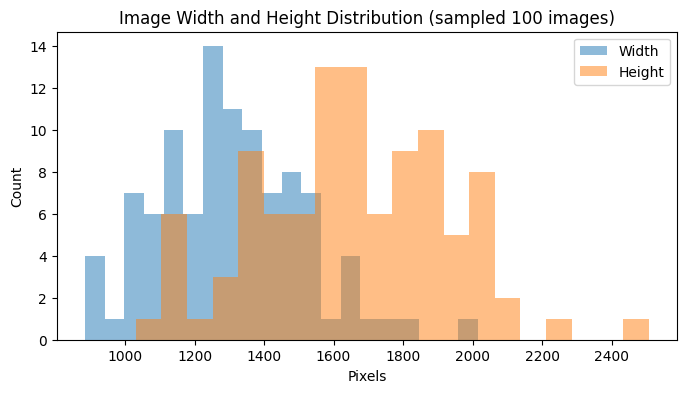

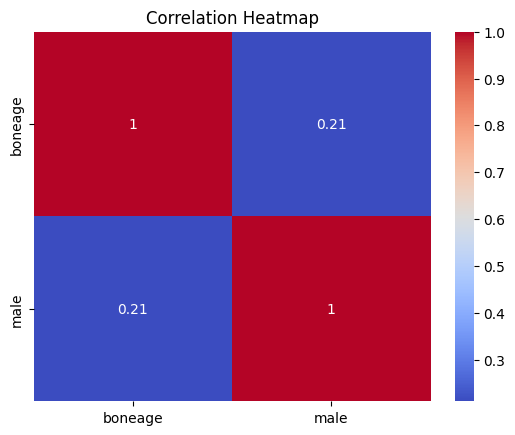

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

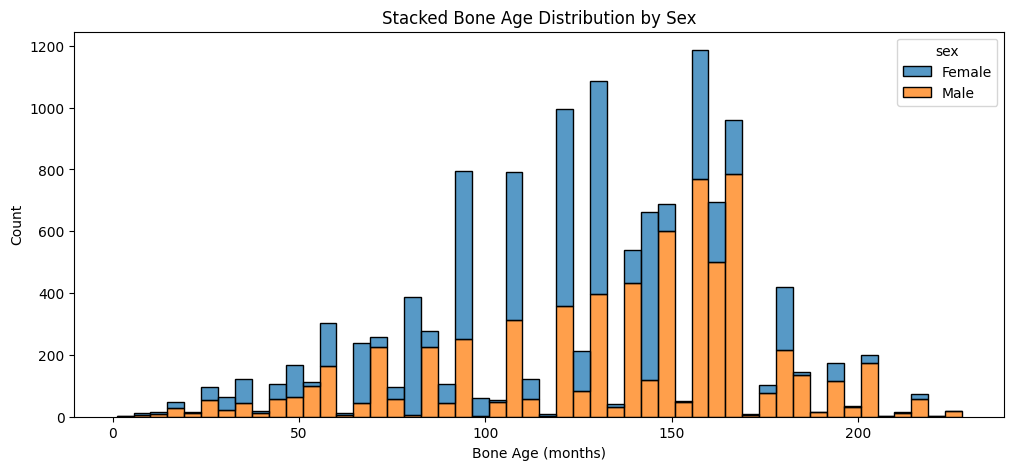

In [ ]:
# ===============================
# 1️ Import Libraries
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import numpy as np

# ===============================
# 2️ Load Dataset
# ===============================
dataset_path = "/kaggle/input/rsna-bone-age"
train_labels = pd.read_csv(f"{dataset_path}/boneage-training-dataset.csv")
test_labels = pd.read_csv(f"{dataset_path}/boneage-test-dataset.csv")

print("Train shape:", train_labels.shape)
print("Test shape:", test_labels.shape)
train_labels.head()

# ===============================
# 3️ Fix Gender Column
# ===============================
# male column is boolean: True = Male, False = Female
train_labels['sex'] = train_labels['male'].map({False:'Female', True:'Male'})
print(train_labels[['male','sex']].head(10))

# ===============================
# 4️ Basic Info
# ===============================
print("Columns:", train_labels.columns)
print("Missing values:\n", train_labels.isnull().sum())
print("Bone age range:", train_labels['boneage'].min(), "-", train_labels['boneage'].max())
print("Unique sexes:", train_labels['sex'].unique())

# ===============================
# 5️ Bone Age Distribution
# ===============================
plt.figure(figsize=(10,5))
sns.histplot(train_labels['boneage'], bins=50, kde=True, color='teal')
plt.title("Bone Age Distribution")
plt.xlabel("Bone Age (months)")
plt.ylabel("Count")
plt.show()

# ===============================
# 6️ Distribution by Sex
# ===============================
plt.figure(figsize=(6,4))
sns.countplot(x='sex', data=train_labels)
plt.title("Distribution by Sex")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(train_labels[train_labels['sex']=='Male']['boneage'], bins=50, color='blue', label='Male', kde=True)
sns.histplot(train_labels[train_labels['sex']=='Female']['boneage'], bins=50, color='pink', label='Female', kde=True)
plt.title("Bone Age Distribution by Sex")
plt.xlabel("Bone Age (months)")
plt.ylabel("Count")
plt.legend()
plt.show()

# ===============================
# 7️ Sample Images
# ===============================
image_dir = f"{dataset_path}/boneage-training-dataset/boneage-training-dataset"
sample_ids = train_labels['id'].sample(8, random_state=42)
plt.figure(figsize=(16,6))

files_in_dir = os.listdir(image_dir)

for i, img_id in enumerate(sample_ids):
    matching_files = [f for f in files_in_dir if f.startswith(str(img_id))]
    if len(matching_files) == 0:
        continue
    img_path = os.path.join(image_dir, matching_files[0])
    img = Image.open(img_path)
    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"{train_labels[train_labels['id']==img_id]['boneage'].values[0]} mo")
plt.show()

# ===============================
# 8️ Image Sizes (sampled)
# ===============================
sizes = []
for img_file in train_labels['id'].values[:100]:  # sample 100 images for speed
    matching_files = [f for f in files_in_dir if f.startswith(str(img_file))]
    if len(matching_files) == 0:
        continue
    img_path = os.path.join(image_dir, matching_files[0])
    img = Image.open(img_path)
    sizes.append(img.size)
sizes = np.array(sizes)
print("Image size stats (WxH):", sizes[:,0].min(), "-", sizes[:,0].max(), "x", sizes[:,1].min(), "-", sizes[:,1].max())

plt.figure(figsize=(8,4))
plt.hist(sizes[:,0], bins=20, alpha=0.5, label='Width')
plt.hist(sizes[:,1], bins=20, alpha=0.5, label='Height')
plt.title("Image Width and Height Distribution (sampled 100 images)")
plt.xlabel("Pixels")
plt.ylabel("Count")
plt.legend()
plt.show()

# ===============================
# 9️ Correlation Heatmap
# ===============================
corr = train_labels[['boneage','male']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ===============================
# 10 Stacked Histogram by Sex
# ===============================
plt.figure(figsize=(12,5))
sns.histplot(data=train_labels, x='boneage', hue='sex', multiple='stack', bins=50)
plt.title("Stacked Bone Age Distribution by Sex")
plt.xlabel("Bone Age (months)")
plt.ylabel("Count")
plt.show()


In [4]:
!pip install --upgrade protobuf==3.20.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-cloud-translate 3.12.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 3.20.1 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.1 which is incompatible.
google-cloud-secret-manager 2.25.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 3.20.1 which is incompatible.
google-cloud

In [5]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs found:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.18.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [ ]:
import tensorflow as tf
import pandas as pd
import os

# ===============================
# 1️ Load Labels
# ===============================
dataset_path = "/kaggle/input/rsna-bone-age"
train_labels = pd.read_csv(f"{dataset_path}/boneage-training-dataset.csv")

# Fix gender column
train_labels['sex'] = train_labels['male'].map({False:'Female', True:'Male'})

# ===============================
# 2️ Create File Paths
# ===============================
train_folder = f"{dataset_path}/boneage-training-dataset/boneage-training-dataset"

train_labels['file_path'] = train_labels['id'].apply(lambda x: os.path.join(
    train_folder, [f for f in os.listdir(train_folder) if f.startswith(str(x))][0]
))

# ===============================
# 3️ TensorFlow Preprocessing Function
# ===============================
IMG_SIZE = (224, 224)

def preprocess_image(img_path, label):
    # Read image
    img = tf.io.read_file(img_path)
    # Decode PNG grayscale
    img = tf.image.decode_png(img, channels=1)
    # Resize
    img = tf.image.resize(img, IMG_SIZE)
    # Normalize to 0-1
    img = img / 255.0
    # Convert to 3 channels
    img = tf.repeat(img, repeats=3, axis=-1)
    return img, label

# ===============================
# 4️ Create TensorFlow Dataset
# ===============================
file_paths = train_labels['file_path'].values
labels = train_labels['boneage'].values.astype('float32')

dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(buffer_size=1000)
dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)

# ===============================
# 5️ Train-Validation Split
# ===============================
from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels_arr, val_labels_arr = train_test_split(
    file_paths, labels, test_size=0.1, random_state=42
)

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels_arr))
train_ds = train_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels_arr))
val_ds = val_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

print("GPU-enabled preprocessing pipeline ready!")


GPU-enabled preprocessing pipeline ready!


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(1)   # ✅ Regression → SINGLE NUMBER OUTPUT
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse',                 # ✅ Regression loss
    metrics=['mae']             # ✅ Regression metric
)

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    verbose=1
)


Epoch 1/20


I0000 00:00:1764662608.283761     112 service.cc:148] XLA service 0x7d5300004dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764662608.284586     112 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764662608.284606     112 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764662608.680130     112 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/355 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - loss: 18964.5664 - mae: 129.7314   

I0000 00:00:1764662613.601939     112 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


355/355 ━━━━━━━━━━━━━━━━━━━━ 157s 389ms/step - loss: 5560.8252 - mae: 58.2919 - val_loss: 1719.8257 - val_mae: 33.6136
Epoch 2/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 114s 297ms/step - loss: 1898.1477 - mae: 35.3870 - val_loss: 1690.9993 - val_mae: 34.1165
Epoch 3/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 125s 327ms/step - loss: 1754.1600 - mae: 34.0152 - val_loss: 1544.8223 - val_mae: 32.0800
Epoch 4/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 115s 297ms/step - loss: 1677.1140 - mae: 33.1237 - val_loss: 1477.0312 - val_mae: 31.4383
Epoch 5/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 114s 297ms/step - loss: 1552.1161 - mae: 31.7089 - val_loss: 1378.4325 - val_mae: 29.9594
Epoch 6/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 115s 298ms/step - loss: 1434.2305 - mae: 30.3835 - val_loss: 1273.5433 - val_mae: 28.1497
Epoch 7/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 115s 298ms/step - loss: 1395.4363 - mae: 29.8470 - val_loss: 1220.2761 - val_mae: 27.7356
Epoch 8/20
355/355 ━━━━━━━━━━━━━━━━━━━━ 119s 311ms/step - loss: 1362.4438 - mae: 29.3634 - val_loss: 

In [10]:
import numpy as np
from sklearn.metrics import r2_score

# Predictions
y_true = np.concatenate([y for x,y in val_ds])
y_pred = model.predict(val_ds).flatten()

# Metrics
mae  = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
r2   = r2_score(y_true, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 270ms/step
MAE : 23.13102
RMSE: 30.72826
R2  : 0.45669979767541846


In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Base pretrained model
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

# Regression head
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
output = Dense(1)(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(1e-4),
    loss='mse',
    metrics=['mae']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)


Epoch 1/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 131s 318ms/step - loss: 10360.5352 - mae: 89.8200 - val_loss: 1839.9495 - val_mae: 35.1361
Epoch 2/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 113s 293ms/step - loss: 1676.5002 - mae: 33.5990 - val_loss: 1300.1461 - val_mae: 29.4995
Epoch 3/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 113s 293ms/step - loss: 1191.7114 - mae: 28.1782 - val_loss: 997.5897 - val_mae: 25.1837
Epoch 4/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 113s 292ms/step - loss: 933.4659 - mae: 24.4555 - val_loss: 871.5519 - val_mae: 22.9105
Epoch 5/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 113s 292ms/step - loss: 821.6667 - mae: 22.5717 - val_loss: 807.6827 - val_mae: 21.8748
Epoch 6/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 113s 293ms/step - loss: 767.7090 - mae: 21.6353 - val_loss: 767.9504 - val_mae: 21.1653
Epoch 7/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 113s 294ms/step - loss: 719.3986 - mae: 20.8598 - val_loss: 743.5079 - val_mae: 20.7691
Epoch 8/15
355/355 ━━━━━━━━━━━━━━━━━━━━ 113s 293ms/step - loss: 694.3826 - mae: 20.5261 - val_loss

In [13]:
y_true = np.concatenate([y for x,y in val_ds])
y_pred = model.predict(val_ds).flatten()

from sklearn.metrics import r2_score

mae  = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
r2   = r2_score(y_true, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 322ms/step
MAE : 19.210325
RMSE: 25.43136
R2  : 0.6278627632214506


In [14]:
# Unfreeze last 50 layers
for layer in base_model.layers[-50:]:
    layer.trainable = True 

model.compile(
    optimizer=Adam(1e-5),
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)


Epoch 1/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 143s 326ms/step - loss: 2197.3950 - mae: 36.2121 - val_loss: 3289.9968 - val_mae: 52.2430
Epoch 2/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 114s 297ms/step - loss: 561.4471 - mae: 18.3203 - val_loss: 2093.4695 - val_mae: 40.4538
Epoch 3/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 114s 296ms/step - loss: 441.5894 - mae: 16.0666 - val_loss: 1325.4352 - val_mae: 30.9928
Epoch 4/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 114s 296ms/step - loss: 398.0900 - mae: 15.2544 - val_loss: 740.5275 - val_mae: 21.9192
Epoch 5/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 115s 298ms/step - loss: 338.6305 - mae: 14.1091 - val_loss: 609.0275 - val_mae: 19.6988
Epoch 6/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 124s 325ms/step - loss: 298.9008 - mae: 13.2962 - val_loss: 486.4661 - val_mae: 17.2050
Epoch 7/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 114s 296ms/step - loss: 267.3973 - mae: 12.5323 - val_loss: 427.6857 - val_mae: 15.7703
Epoch 8/10
355/355 ━━━━━━━━━━━━━━━━━━━━ 114s 296ms/step - loss: 244.9836 - mae: 11.9572 - val_loss: 

In [15]:
y_true = np.concatenate([y for x,y in val_ds])
y_pred = model.predict(val_ds).flatten()

from sklearn.metrics import r2_score

print("MAE :", np.mean(np.abs(y_true - y_pred)))
print("RMSE:", np.sqrt(np.mean((y_true - y_pred)**2)))
print("R2  :", r2_score(y_true, y_pred))


40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 316ms/step
MAE : 15.104334
RMSE: 20.203905
R2  : 0.7651261659463664


40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 271ms/step
MAE  : 15.10
RMSE : 20.20
R²   : 0.765


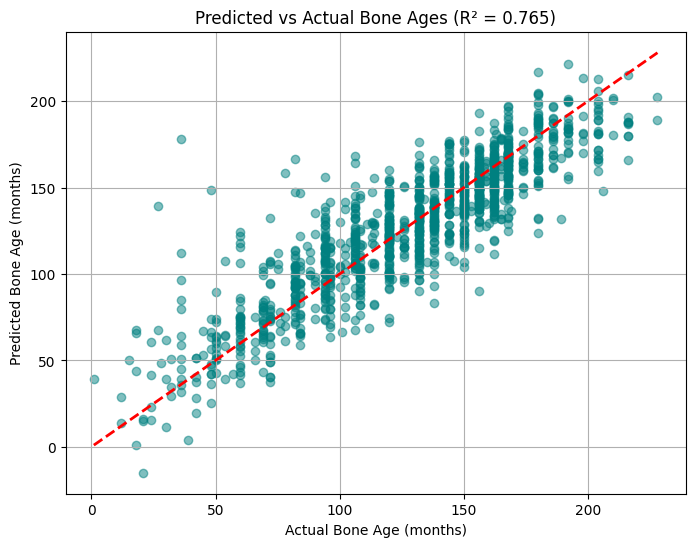

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# ===============================
# 1️ Extract true labels and predictions
# ===============================
y_true = np.concatenate([y for x, y in val_ds])
y_pred = model.predict(val_ds).flatten()

# ===============================
# 2️ Compute metrics (optional, for display)
# ===============================
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))
r2 = r2_score(y_true, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

# ===============================
# 3️ Scatter plot: Predicted vs True Bone Ages
# ===============================
plt.figure(figsize=(8,6))
plt.scatter(y_true, y_pred, alpha=0.5, color='teal')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', linewidth=2)  # ideal line
plt.xlabel("Actual Bone Age (months)")
plt.ylabel("Predicted Bone Age (months)")
plt.title(f"Predicted vs Actual Bone Ages (R² = {r2:.3f})")
plt.grid(True)
plt.show()


In [17]:
import pandas as pd
import numpy as np

results = pd.DataFrame({
    "True Age": y_true,
    "Predicted Age": y_pred
})

# Map gender
results["Male"] = train_labels.iloc[:len(results)]["male"].values

for g in [True, False]:
    subset = results[results["Male"] == g]
    mae = np.mean(np.abs(subset["True Age"] - subset["Predicted Age"]))
    print("Male" if g else "Female", "MAE:", round(mae,2))


Male MAE: 15.25
Female MAE: 14.92


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_11']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


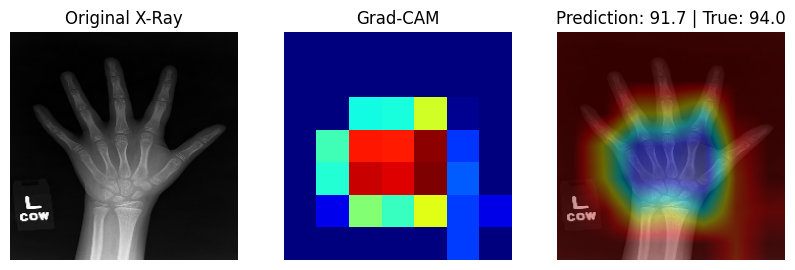

In [18]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
# Change this ONLY if your model layer name differs
LAST_CONV_LAYER = "Conv_1"

IMG_SIZE = (224,224)

# --------------------------------------------------
# GRAD-CAM FUNCTION
# --------------------------------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

# --------------------------------------------------
# APPLY CAM TO IMAGE
# --------------------------------------------------
def superimpose_heatmap(heatmap, img):

    heatmap = cv2.resize(heatmap, IMG_SIZE)
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    return superimposed


# --------------------------------------------------
# VISUALIZE SAMPLE FROM VAL DATASET
# --------------------------------------------------

# Take 1 batch from validation set
for images, labels in val_ds.take(1):
    sample = images[0]
    true_age = labels[0].numpy()

    break

# Predict
pred_age = model.predict(sample[None,...])[0][0]

# Convert for CAM
img_array = tf.expand_dims(sample, axis=0)

# Generate heatmap
heatmap = make_gradcam_heatmap(img_array, model, LAST_CONV_LAYER)

# Convert img [0..1] -> [0..255]
orig_img = np.uint8(sample.numpy()*255)

# Overlay cam
cam_img = superimpose_heatmap(heatmap, orig_img)

# --------------------------------------------------
# DISPLAY
# --------------------------------------------------

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(orig_img)
plt.title("Original X-Ray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cam_img)
plt.title(f"Prediction: {pred_age:.1f} | True: {true_age:.1f}")
plt.axis("off")

plt.show()
